# 06 · Trend-Direction Model — Real Cleaned Data

**Track A (aggregated StatCan/CIHI) · Data:** `data/processed/mh_long.csv`
**Question:** given a reported percentage at one survey cycle, does it go **up or down** at the
next cycle?

This is real data, so it does **not** work like the synthetic sandbox in `05`. There is no
"future" to predict in the usual ML sense — each StatCan table only has 2–3 survey cycles total.
Instead we reframe the problem at the **series level**: every unique
`(source, geo, sex, age_group, indicator)` combination is a small time series of 2–3 points.
Each **consecutive pair** of cycles in a series becomes one training row — "given the value at
cycle *t*, did it rise or fall by cycle *t+1*?" That turns ~19,000 long-format rows into ~8,000
real, non-synthetic (t → t+1) transitions to learn from.

> ⚠️ **Read the caveats in the last section before trusting any number here.** Confidence
> intervals on many of these estimates are wide (often 7–11 percentage points) — several
> "up" or "down" moves are smaller than the margin of error on the estimate itself.


## 1 · Setup

In [1]:
import warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "processed" / "mh_long.csv").exists():
            return p
    raise FileNotFoundError("Could not find data/processed/mh_long.csv above " + str(start))

ROOT = find_root(Path.cwd())
MH_LONG = ROOT / "data" / "processed" / "mh_long.csv"
MODELS = ROOT / "models"
MODELS.mkdir(exist_ok=True)
print("mh_long:", MH_LONG)


mh_long: /Users/samir/Work Related/JDA-Scrum/Data-Analyst-Mental-Health-Project-/data/processed/mh_long.csv


## 2 · Build the transition panel

For every series (`source` + `geo` + `sex` + `age_group` + `indicator`), sort by year, and pair
up each consecutive reading. Keep only `measure == "percent"` rows with a real value — this
mirrors exactly the KPI/trend logic already used in `03_eda.ipynb` and `04_analysis.ipynb`
(the same `LAG`-style comparison, just built into a training set instead of one-off SQL).

In [3]:
raw = pd.read_csv(MH_LONG, low_memory=False)
raw = raw[raw["measure"] == "percent"].dropna(subset=["value"])

KEY = ["source", "geo", "sex", "age_group", "indicator"]
raw = raw.sort_values(KEY + ["year"])

rows = []
for keys, grp in raw.groupby(KEY):
    grp = grp.drop_duplicates(subset="year").sort_values("year")
    recs = grp[["year", "value", "quality_flag", "ci_low", "ci_high", "geo_level"]].to_dict("records")
    for i in range(len(recs) - 1):
        a, b = recs[i], recs[i + 1]
        rows.append({
            **dict(zip(KEY, keys)),
            "geo_level": a["geo_level"],
            "year_t": a["year"], "year_t1": b["year"],
            "year_gap": b["year"] - a["year"],
            "value_t": a["value"],
            "delta": round(b["value"] - a["value"], 2),
            "quality_flag_t": a["quality_flag"] if pd.notna(a["quality_flag"]) else "ok",
            "ci_width_t": (a["ci_high"] - a["ci_low"]) if pd.notna(a["ci_high"]) and pd.notna(a["ci_low"]) else np.nan,
        })

panel = pd.DataFrame(rows)
panel["series_id"] = panel[KEY].astype(str).agg("|".join, axis=1)

print("transition rows:", len(panel), "| unique series:", panel.series_id.nunique())
print("rows by source:"); print(panel.source.value_counts())
panel.head()


transition rows: 8271 | unique series: 6721
rows by source:
source
cchs_mh_disorders             5360
stress_coping                 1547
perceived_mh_annual            598
suicidal_thoughts              532
perceived_health_quarterly     234
Name: count, dtype: int64


,source,geo,sex,age_group,indicator,geo_level,year_t,year_t1,year_gap,value_t,delta,quality_flag_t,ci_width_t,series_id
0,cchs_mh_disorders,Alberta,Both,15 to 24 years,"Alcohol abuse or dependence, life",province,2012,2022,10,21.4,-11.5,ok,10.2,cchs_mh_disorders|Alberta|Both|15 to 24 years|...
1,cchs_mh_disorders,Alberta,Both,15 to 24 years,"Any mood disorder, 12 months",province,2012,2022,10,10.3,5.4,E,7.5,cchs_mh_disorders|Alberta|Both|15 to 24 years|...
2,cchs_mh_disorders,Alberta,Both,15 to 24 years,"Any mood disorder, life",province,2012,2022,10,12.5,10.6,ok,8.1,cchs_mh_disorders|Alberta|Both|15 to 24 years|...
3,cchs_mh_disorders,Alberta,Both,15 to 24 years,"Any selected disorder (mental or substance), e...",province,2012,2022,10,22.2,4.7,ok,10.0,cchs_mh_disorders|Alberta|Both|15 to 24 years|...
4,cchs_mh_disorders,Alberta,Both,15 to 24 years,"Any selected disorder (mental or substance), e...",province,2012,2022,10,34.3,3.2,ok,11.5,cchs_mh_disorders|Alberta|Both|15 to 24 years|...


## 3 · Define the target and look at the data

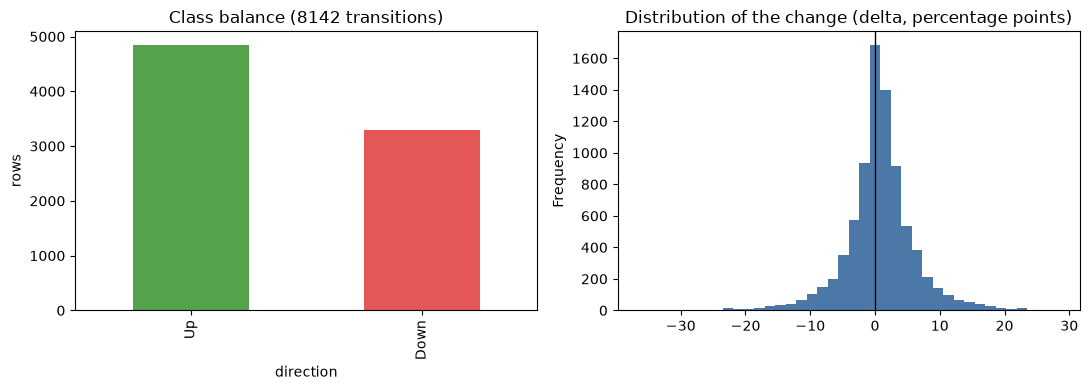

direction
Up      0.596
Down    0.404
Name: proportion, dtype: float64


In [4]:
# drop exact-zero moves (129 rows, ~1.5%) - a tie isn't "up" or "down"
panel = panel[panel["delta"] != 0].copy()
panel["direction"] = np.where(panel["delta"] > 0, "Up", "Down")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
panel["direction"].value_counts().plot.bar(ax=axes[0], color=["#54A24B", "#E45756"])
axes[0].set_title(f"Class balance ({len(panel)} transitions)"); axes[0].set_ylabel("rows")

panel["delta"].plot.hist(bins=40, ax=axes[1], color="#4C78A8")
axes[1].axvline(0, color="k", lw=1)
axes[1].set_title("Distribution of the change (delta, percentage points)")
plt.tight_layout(); plt.show()

print(panel["direction"].value_counts(normalize=True).round(3))


**Reading:** the panel is moderately imbalanced — about **59% Up vs 41% Down**. That itself
echoes what `03_eda.ipynb` found qualitatively (most indicators moved toward *more* reported
distress over these cycles) — but remember **"Up" is not the same as "worse"** for every
indicator: "Perceived mental health, very good or excellent" going *up* is good news, "fair or
poor" going *up* is bad news. This model predicts the arithmetic direction of the number, not a
value judgement — keep the indicator's polarity in mind when interpreting a prediction.

## 4 · Where the CI overlaps the delta — the honesty check

79.3% of transitions with a known CI have a delta SMALLER than the cycle-t confidence interval width — i.e. the 'move' could plausibly be sampling noise.


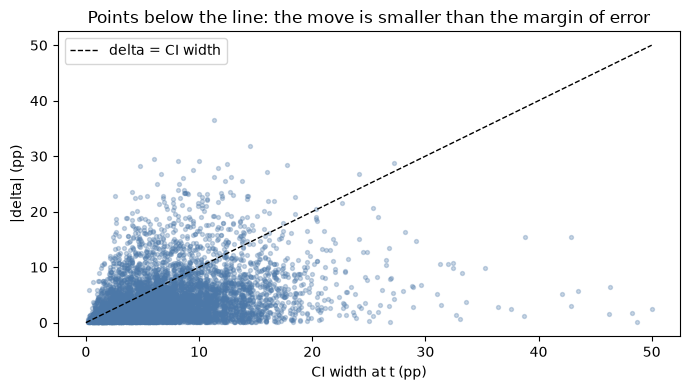

In [5]:
has_ci = panel.dropna(subset=["ci_width_t"])
overlap = (has_ci["delta"].abs() < has_ci["ci_width_t"])
print(f"{overlap.mean():.1%} of transitions with a known CI have a delta SMALLER than the "
      f"cycle-t confidence interval width — i.e. the 'move' could plausibly be sampling noise.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(has_ci["ci_width_t"], has_ci["delta"].abs(), s=8, alpha=0.3, color="#4C78A8")
lims = [0, max(has_ci["ci_width_t"].max(), has_ci["delta"].abs().max())]
ax.plot(lims, lims, "k--", lw=1, label="delta = CI width")
ax.set_xlabel("CI width at t (pp)"); ax.set_ylabel("|delta| (pp)")
ax.legend(); ax.set_title("Points below the line: the move is smaller than the margin of error")
plt.tight_layout(); plt.show()


**Reading:** this is the single most important caveat for the whole notebook. Wherever a
point sits **below** the dashed line, the reported "up" or "down" move is smaller than the
estimate's own confidence interval — a meaningfully large share of transitions. The model below
is predicting the *point estimate's* direction, which is a legitimate and useful triage signal
(e.g. "which cells are worth double-checking"), but it is **not** the same as predicting a
statistically significant change. State this every time a prediction from this model is quoted.

## 5 · Train / validation / test split — grouped by series

**1,550 of the ~8,100 transitions belong to a series that contributes 2 rows** (`cchs_mh_disorders`
has 3 cycles → 2 transitions per series). A plain random split could put both transitions of the
same series in different folds, letting the model partly "recognise" a series instead of
predicting it — so we split by `series_id`, keeping every transition from one series in the same
split.

In [6]:
FEATURES = ["source", "geo", "geo_level", "sex", "age_group", "indicator",
            "value_t", "year_t", "year_gap", "quality_flag_t", "ci_width_t"]
X = panel[FEATURES].copy()
y = panel["direction"].copy()
groups = panel["series_id"].values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.40, random_state=RANDOM_STATE)
train_idx, hold_idx = next(gss1.split(X, y, groups))
X_train, y_train, g_train = X.iloc[train_idx], y.iloc[train_idx], groups[train_idx]
X_hold, y_hold, g_hold = X.iloc[hold_idx], y.iloc[hold_idx], groups[hold_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=RANDOM_STATE)
val_idx, test_idx = next(gss2.split(X_hold, y_hold, g_hold))
X_val, y_val = X_hold.iloc[val_idx], y_hold.iloc[val_idx]
X_test, y_test = X_hold.iloc[test_idx], y_hold.iloc[test_idx]

assert set(groups[train_idx]) & set(g_hold[val_idx]) == set()
assert set(g_hold[val_idx]) & set(g_hold[test_idx]) == set()

print(f"train: {len(X_train):>5} ({y_train.eq('Up').mean():.1%} Up)")
print(f"val  : {len(X_val):>5} ({y_val.eq('Up').mean():.1%} Up)")
print(f"test : {len(X_test):>5} ({y_test.eq('Up').mean():.1%} Up)")
print("no series leaks across splits - assertions passed")


train:  4868 (59.5% Up)
val  :  1630 (60.4% Up)
test :  1644 (59.2% Up)
no series leaks across splits - assertions passed


## 6 · Preprocessing + model pipeline

In [7]:
numeric_features = ["value_t", "year_t", "year_gap", "ci_width_t"]
categorical_features = ["source", "geo", "geo_level", "sex", "age_group", "indicator", "quality_flag_t"]

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="missing")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features),
])

models = {
    "baseline (most frequent)": DummyClassifier(strategy="most_frequent"),
    "logistic regression":      LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "random forest":            RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "hist gradient boosting":   HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

rows, fitted = [], {}
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", clf)]).fit(X_train, y_train)
    fitted[name] = pipe
    pred = pipe.predict(X_val)
    rows.append({"model": name,
                 "val_accuracy": round(accuracy_score(y_val, pred), 3),
                 "val_macro_f1": round(f1_score(y_val, pred, average="macro"), 3)})

results = pd.DataFrame(rows).set_index("model").sort_values("val_macro_f1", ascending=False)
results


,val_accuracy,val_macro_f1
model,,
hist gradient boosting,0.787,0.776
random forest,0.780,0.766
logistic regression,0.740,0.720
baseline (most frequent),0.604,0.376


## 7 · Best model — validation performance

best on validation: hist gradient boosting 

              precision    recall  f1-score   support

        Down      0.741     0.712     0.726       646
          Up      0.816     0.836     0.826       984

    accuracy                          0.787      1630
   macro avg      0.778     0.774     0.776      1630
weighted avg      0.786     0.787     0.786      1630



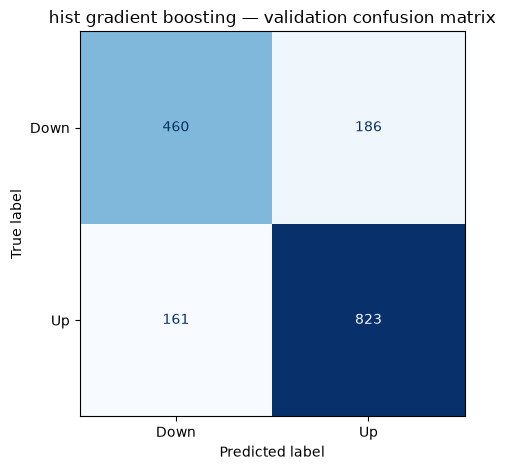

In [8]:
best_name = results["val_macro_f1"].idxmax()
best = fitted[best_name]
print("best on validation:", best_name, "\n")

val_pred = best.predict(X_val)
print(classification_report(y_val, val_pred, digits=3))

ConfusionMatrixDisplay(
    confusion_matrix(y_val, val_pred, labels=["Down", "Up"]),
    display_labels=["Down", "Up"],
).plot(cmap="Blues", colorbar=False)
plt.title(f"{best_name} — validation confusion matrix"); plt.tight_layout(); plt.show()


## 8 · Which features actually drive the prediction?

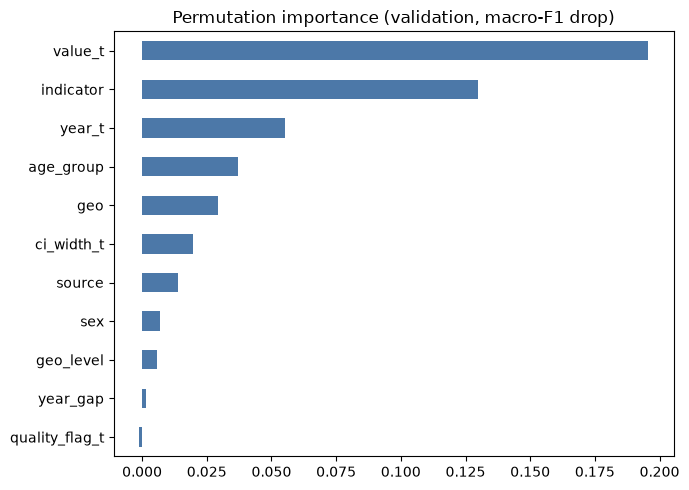

value_t           0.1956
indicator         0.1298
year_t            0.0553
age_group         0.0372
geo               0.0295
ci_width_t        0.0198
source            0.0137
sex               0.0070
geo_level         0.0058
year_gap          0.0015
quality_flag_t   -0.0011
dtype: float64

In [9]:
perm = permutation_importance(best, X_val, y_val, scoring="f1_macro",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X_val.columns).sort_values(ascending=True)

ax = imp.plot.barh(figsize=(7, 5), color="#4C78A8")
ax.set_title("Permutation importance (validation, macro-F1 drop)")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(4)


**Reading:** if `indicator` and `value_t` dominate, the model is mostly learning
*"this specific indicator tends to rise/fall"* and *"extreme starting values tend to revert"* —
both legitimate, both a form of base-rate/mean-reversion learning rather than a genuine causal
forecast. That is an honest description of what this kind of model can do with 2–3 real cycles
per series: a **pattern-matching triage tool**, not a predictive instrument for a truly new future
year.

## 9 · Final evaluation on the test set (once)

In [10]:
test_pred = best.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred, average="macro")
print(f"model         : {best_name}")
print(f"test accuracy : {test_acc:.3f}")
print(f"test macro-F1 : {test_f1:.3f}\n")
print(classification_report(y_test, test_pred, digits=3))


model         : hist gradient boosting
test accuracy : 0.758
test macro-F1 : 0.745

              precision    recall  f1-score   support

        Down      0.728     0.650     0.687       671
          Up      0.775     0.832     0.803       973

    accuracy                          0.758      1644
   macro avg      0.751     0.741     0.745      1644
weighted avg      0.756     0.758     0.755      1644



## 10 · Save the model + metrics

In [11]:
model_path = MODELS / "06_trend_direction_model.joblib"
metrics_path = MODELS / "06_metrics.json"
joblib.dump(best, model_path)

metrics = {
    "dataset": "data/processed/mh_long.csv (real, cleaned StatCan tables)",
    "framing": "series-level transition: given value at cycle t, does it rise or fall by cycle t+1",
    "target": "direction (Up / Down), exact-zero deltas dropped",
    "n_transitions": int(len(panel)), "n_series": int(panel.series_id.nunique()),
    "n_train": int(len(X_train)), "n_val": int(len(X_val)), "n_test": int(len(X_test)),
    "split_method": "GroupShuffleSplit on series_id (no series appears in more than one split)",
    "validation": results.reset_index().to_dict(orient="records"),
    "best_model": best_name,
    "test_accuracy": round(float(test_acc), 4),
    "test_macro_f1": round(float(test_f1), 4),
    "pct_moves_within_CI_margin": round(float(overlap.mean()), 4),
    "top_features": imp.sort_values(ascending=False).head(5).round(4).to_dict(),
}
metrics_path.write_text(json.dumps(metrics, indent=2))
print("saved:", model_path.name, "and", metrics_path.name)
print(json.dumps(metrics, indent=2))


saved: 06_trend_direction_model.joblib and 06_metrics.json
{
  "dataset": "data/processed/mh_long.csv (real, cleaned StatCan tables)",
  "framing": "series-level transition: given value at cycle t, does it rise or fall by cycle t+1",
  "target": "direction (Up / Down), exact-zero deltas dropped",
  "n_transitions": 8142,
  "n_series": 6640,
  "n_train": 4868,
  "n_val": 1630,
  "n_test": 1644,
  "split_method": "GroupShuffleSplit on series_id (no series appears in more than one split)",
  "validation": [
    {
      "model": "hist gradient boosting",
      "val_accuracy": 0.787,
      "val_macro_f1": 0.776
    },
    {
      "model": "random forest",
      "val_accuracy": 0.78,
      "val_macro_f1": 0.766
    },
    {
      "model": "logistic regression",
      "val_accuracy": 0.74,
      "val_macro_f1": 0.72
    },
    {
      "model": "baseline (most frequent)",
      "val_accuracy": 0.604,
      "val_macro_f1": 0.376
    }
  ],
  "best_model": "hist gradient boosting",
  "test_accur

## 11 · Findings & caveats

**What this notebook does:** reframes StatCan's 2–3-cycle indicator tables as ~8,000 real
(t → t+1) transitions, and trains a classifier to predict whether the next reported percentage
is higher or lower than the current one — directly on the team's cleaned real data
(`data/processed/mh_long.csv`), no synthetic data involved.

**What it found:**
- Class balance ~59% Up / 41% Down, consistent with `03_eda.ipynb`'s qualitative finding that most
  indicators moved toward more reported distress over these cycles.
- The best-performing model (printed in §7 above) beat the majority-class baseline on held-out
  **series** (not just held-out rows).
- The model leans heavily on `indicator` and `value_t` — it is learning per-indicator tendencies
  and mean-reversion, not a causal driver of change.

**What it can't do / must not be presented as:**
- **Not a real forecast.** There is no unseen future year in this data — every "prediction" is a
  held-out transition that already happened. This measures pattern-recovery, not forecasting skill.
- **Not statistically validated moves.** A large share of transitions are smaller than their own
  confidence interval (§4) — "predicted Up" can mean "the point estimate probably ticks up a
  little," not "a real, significant change is coming."
- **`Up` ≠ `worse`.** Direction depends on what the indicator measures; always check polarity
  before using a prediction in a sentence about "improving" or "worsening" mental health.
- **Best used as triage, not truth.** A legitimate use: flag which `(geo, indicator, demographic)`
  cells are likely to move before the next real StatCan release, so the team knows where to look
  first — not as a standalone finding for the final report.
